In [54]:
import polars as pl
import matplotlib
import numpy as np
import math
import pyarrow as pa
import IProgress
import hashlib
import io
from PIL import Image
from pathlib import Path
import plotly.express as px
import nbformat

In [55]:
print(pl.__version__)
print(pa.__version__)

1.40.0
23.0.1


In [56]:
# Import dataset
splits = {'train': 'data/train-00000-of-00001.parquet', 'validation': 'data/validation-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}
df_train = pl.read_parquet('hf://datasets/mmenendezg/pneumonia_x_ray/' + splits['train'])
df_test = pl.read_parquet('hf://datasets/mmenendezg/pneumonia_x_ray/' + splits['test'])
df_val = pl.read_parquet('hf://datasets/mmenendezg/pneumonia_x_ray/' + splits['validation'])

The original splits contained overlapping images (based on hashed bytes). By concatenating the three splits and removing duplicate images, I can resplit the data without leakage.

In [57]:
df = pl.concat([df_train, df_test, df_val])

#### First look

In [58]:
df.head

<bound method DataFrame.head of shape: (5_856, 2)
┌─────────────────────────────────┬───────┐
│ image                           ┆ label │
│ ---                             ┆ ---   │
│ struct[2]                       ┆ i64   │
╞═════════════════════════════════╪═══════╡
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 0     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 0     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 0     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 0     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 0     │
│ …                               ┆ …     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 1     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 1     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 1     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 1     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 1     │
└─────────────────────────────────┴───────┘>

In [59]:
df.schema

Schema([('image', Struct({'bytes': Binary, 'path': String})),
        ('label', Int64)])

In [60]:
df.group_by("label").len()

label,len
i64,u32
0,1583
1,4273


### Check for duplicates

In [61]:
total_rows = df.height
unique_paths = df.select(pl.col("image").struct.field("path").n_unique()).item()
unique_hashes = df.select(pl.col("image").struct.field("bytes").hash().n_unique()).item()

print("Total rows:", total_rows)
print("Unique paths:", unique_paths)
print("Unique hashes:", unique_hashes)

Total rows: 5856
Unique paths: 4273
Unique hashes: 5383


It seems like a decent number of images use the same path, but only a few of the images are actually identical.

In [62]:
# Add image_hash and image_path columns
df = df.with_columns(pl.col("image").struct.field("bytes").hash().alias("image_hash"))
df = df.with_columns(pl.col("image").struct.field("path").alias("image_path"))
df.head(5)

image,label,image_hash,image_path
struct[2],i64,u64,str
"{b""\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\x09\x09\x08\x0a\x0c\x14\x0d\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c\x20""…,""train-0.jpeg""}",0,15624522136123532950,"""train-0.jpeg"""
"{b""\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\x09\x09\x08\x0a\x0c\x14\x0d\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c\x20""…,""train-1.jpeg""}",0,18221970835360844062,"""train-1.jpeg"""
"{b""\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\x09\x09\x08\x0a\x0c\x14\x0d\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c\x20""…,""train-10.jpeg""}",0,9990647761240806942,"""train-10.jpeg"""
"{b""\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\x09\x09\x08\x0a\x0c\x14\x0d\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c\x20""…,""train-100.jpeg""}",0,10330418483954177345,"""train-100.jpeg"""
"{b""\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\x09\x09\x08\x0a\x0c\x14\x0d\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c\x20""…,""train-1000.jpeg""}",0,13266960183753597657,"""train-1000.jpeg"""


In [63]:
exact_dupes = df.filter(
    pl.struct(["image_hash", "label", "image_path"]).is_duplicated()
)
len(exact_dupes)

0

In [64]:
hash_dupes = df.filter(pl.struct(["image_hash"]).is_duplicated())
len(hash_dupes)

937

In [65]:
# Find out if any duplicate hashes have different labels
dup_hashes = (
    df.group_by("image_hash")
    .agg([
        pl.col("image_path").n_unique().alias("unique_paths"),
        pl.col("label").n_unique().alias("unique_labels")
    ])
    .filter(pl.col("unique_paths") > 1)
)

print("Duplicate hashes:", len(dup_hashes))


Duplicate hashes: 464


In [66]:
dup_hashes.sort(pl.col("unique_labels"), descending=True)

image_hash,unique_paths,unique_labels
u64,u32,u32
669339071897976533,2,1
13233014610876658831,2,1
15101383923488640199,2,1
7831541357361398896,2,1
13378602015511003333,2,1
…,…,…
3831662230079871873,2,1
14846968372708179429,2,1
8335306669402464873,2,1


It appears that duplicate image hashes all have identical labels, just unique paths. Because there is not overlap, it is safe to drop the duplicates.

In [67]:
# Drop the duplicates
df = df.unique(subset='image_hash')

In [68]:
print("Rows after removing duplicates: ", df.height)
print(df.group_by("label").len())

Rows after removing duplicates:  5383
shape: (2, 2)
┌───────┬──────┐
│ label ┆ len  │
│ ---   ┆ ---  │
│ i64   ┆ u32  │
╞═══════╪══════╡
│ 0     ┆ 1467 │
│ 1     ┆ 3916 │
└───────┴──────┘


### Saving images, renaming files to hashes

In [69]:
# New folder for images
out_dir = Path("data/clean_xrays")
out_dir.mkdir(parents=True, exist_ok=True)

In [70]:
# Shuffle the data
df = df.sample(fraction=1, seed=12)

In [71]:
df.schema

Schema([('image', Struct({'bytes': Binary, 'path': String})),
        ('label', Int64),
        ('image_hash', UInt64),
        ('image_path', String)])

In [72]:
def save_image(image_struct, image_hash):
    """
    Save an image from raw bytes to disk using a hash-based filename.
    Returns file path to the image
    """
    image_bytes = image_struct['bytes']
    out_path = (out_dir / f"{image_hash}.png")

    if not out_path.exists():
        img = Image.open(io.BytesIO(image_bytes))
        img.save(out_path)
    return out_path.as_posix()


In [73]:
df = df.with_columns(
    pl.struct(["image", "image_hash"])
    .map_elements(
        lambda row: save_image(row["image"], row["image_hash"]),
        return_dtype=pl.String
    )
    .alias("file_path")
)

In [74]:
df = df.select(['file_path', 'image_hash', 'label'])

In [75]:
df.head

<bound method DataFrame.head of shape: (5_383, 3)
┌─────────────────────────────────┬──────────────────────┬───────┐
│ file_path                       ┆ image_hash           ┆ label │
│ ---                             ┆ ---                  ┆ ---   │
│ str                             ┆ u64                  ┆ i64   │
╞═════════════════════════════════╪══════════════════════╪═══════╡
│ data/clean_xrays/1126480666513… ┆ 11264806665138737235 ┆ 0     │
│ data/clean_xrays/4284045417672… ┆ 4284045417672651080  ┆ 1     │
│ data/clean_xrays/1138531225824… ┆ 11385312258241916384 ┆ 1     │
│ data/clean_xrays/1843029432740… ┆ 18430294327401452336 ┆ 0     │
│ data/clean_xrays/5038006814766… ┆ 5038006814766199886  ┆ 0     │
│ …                               ┆ …                    ┆ …     │
│ data/clean_xrays/2337357885504… ┆ 2337357885504477552  ┆ 0     │
│ data/clean_xrays/1470326274563… ┆ 14703262745630509064 ┆ 1     │
│ data/clean_xrays/8975624326262… ┆ 8975624326262888069  ┆ 1     │
│ data/clean

### Train/Test/val split

In [76]:
n = df.height

In [77]:
train_end = int(0.7*n)
val_end = int(0.9*n)

In [78]:
train_df = df[:train_end]
val_df = df[train_end:val_end]
test_df = df[val_end:]

In [79]:
train_counts = (
    train_df.group_by("label")
    .len()
    .with_columns(
        (pl.col("len") / train_df.height).alias("proportion")
    )
)
fig = px.pie(
    train_counts,
    names="label",
    values="proportion",
    title="Train Split Class Distribution"
)
fig.show()

In [80]:
test_counts = (
    test_df.group_by("label")
    .len()
    .with_columns(
        (pl.col("len") / test_df.height).alias("proportion")
    )
)
fig = px.pie(
    test_counts,
    names="label",
    values="proportion",
    title="Test Split Class Distribution"
)
fig.show()

In [81]:
val_counts = (
    val_df.group_by("label")
    .len()
    .with_columns(
        (pl.col("len") / val_df.height).alias("proportion")
    )
)
fig = px.pie(
    val_counts,
    names="label",
    values="proportion",
    title="Validation Split Class Distribution"
)
fig.show()

In [82]:
train_hashes = set(train_df["image_hash"])
val_hashes = set(val_df["image_hash"])
test_hashes = set(test_df["image_hash"])

In [83]:
print("train-val overlap:", len(train_hashes & val_hashes))
print("train-test overlap:", len(train_hashes & test_hashes))
print("val-test overlap:", len(val_hashes & test_hashes))

train-val overlap: 0
train-test overlap: 0
val-test overlap: 0


In [84]:
# label train/val images, concat into one df for fastai
train_df = train_df.with_columns(val = False)
val_df = val_df.with_columns(val = True)
df = pl.concat(
    [
        train_df,
        val_df,
    ],
    how="vertical"
)
df.head

<bound method DataFrame.head of shape: (4_844, 4)
┌─────────────────────────────────┬──────────────────────┬───────┬───────┐
│ file_path                       ┆ image_hash           ┆ label ┆ val   │
│ ---                             ┆ ---                  ┆ ---   ┆ ---   │
│ str                             ┆ u64                  ┆ i64   ┆ bool  │
╞═════════════════════════════════╪══════════════════════╪═══════╪═══════╡
│ data/clean_xrays/1126480666513… ┆ 11264806665138737235 ┆ 0     ┆ false │
│ data/clean_xrays/4284045417672… ┆ 4284045417672651080  ┆ 1     ┆ false │
│ data/clean_xrays/1138531225824… ┆ 11385312258241916384 ┆ 1     ┆ false │
│ data/clean_xrays/1843029432740… ┆ 18430294327401452336 ┆ 0     ┆ false │
│ data/clean_xrays/5038006814766… ┆ 5038006814766199886  ┆ 0     ┆ false │
│ …                               ┆ …                    ┆ …     ┆ …     │
│ data/clean_xrays/1661991170997… ┆ 16619911709978348963 ┆ 1     ┆ true  │
│ data/clean_xrays/1537358449250… ┆ 15373584492504

In [85]:
from PIL import Image
img = Image.open(df['file_path'][0])
print(img.size)
print(img.mode)

(500, 500)
RGB


In [86]:
df_pandas = df.to_pandas()

In [87]:
df_pandas.head()

,file_path,image_hash,label,val
0,data/clean_xrays/11264806665138737235.png,11264806665138737235,0,False
1,data/clean_xrays/4284045417672651080.png,4284045417672651080,1,False
2,data/clean_xrays/11385312258241916384.png,11385312258241916384,1,False
3,data/clean_xrays/18430294327401452336.png,18430294327401452336,0,False
4,data/clean_xrays/5038006814766199886.png,5038006814766199886,0,False


### Fastai/modeling

In [88]:
from fastai.vision.all import *
import torch
import fastai

In [89]:
dls = ImageDataLoaders.from_df(
    df_pandas,
    path='.',
    fn_col='file_path',
    label_col='label',
    valid_col='val',
    seed=12,
    item_tfms=Resize(224),
    batch_tfms=[*aug_transforms(
        do_flip=False,
        flip_vert=False,
        max_rotate=20,
        max_zoom=1.2,
        max_warp=0.2,
        max_lighting=0.2,
        ),
        Normalize.from_stats(*imagenet_stats)
    ]
)

Transforms loosely based on the parameters provided in table 3 of "Pneumonia Detection from Chest X-Ray Images Using Deep Learning and Transfer Learning for Imbalanced Datasets", found here: https://pmc.ncbi.nlm.nih.gov/articles/PMC12344030/#Sec22

In [90]:
model_path = Path('pneumonia_learner.pkl')

if model_path.exists():
    learn = load_learner(model_path)
else:
    learn = vision_learner(
        dls,
        resnet34,
        metrics=[accuracy, Precision(), Recall(), F1Score()]
    )
    learn.fine_tune(5)
    learn.export(model_path)

c:\Users\chris\PycharmProjects\pneumonia-detection\.venv\Lib\site-packages\fastai\learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [91]:
print(type(learn.loss_func))
print(learn.dls)
print(learn.dls.valid)

<class 'fastai.losses.CrossEntropyLossFlat'>


In [92]:
x,y = dls.one_batch()

In [93]:
y

TensorCategory([0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0,
                0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1,
                1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
                1], device='cuda:0')

In [94]:
preds,targs = learn.get_preds(dl=[(x,y)])

In [95]:
# learn = vision_learner(dls, resnet34, metrics=error_rate)
# learn.fine_tune(1, base_lr=0.1)

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
lr_min,lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))

In [97]:
# print(f"{lr_min:.2e}, {lr_steep:.2e}")

In [98]:
# learn = vision_learner(dls, resnet34, metrics=[accuracy, Precision(), Recall(), F1Score()])
# learn.fine_tune(2, base_lr=1e-3)

### resnet34

In [99]:
from fastai.callback.tracker import SaveModelCallback

In [127]:
learn=vision_learner(dls, resnet34, metrics=[accuracy, Precision(), Recall(), F1Score()])
learn.fit_one_cycle(3, 1e-3, cbs=SaveModelCallback(monitor='valid_loss', fname='resnet34'))

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.591870,0.600950,0.855019,0.985981,0.811538,0.890295,00:37
1,0.342704,0.334656,0.914498,0.987252,0.893590,0.938089,00:38
2,0.259514,0.292299,0.929368,0.987535,0.914103,0.949401,00:38


Better model found at epoch 0 with valid_loss value: 0.6009501814842224.
Better model found at epoch 1 with valid_loss value: 0.33465641736984253.
Better model found at epoch 2 with valid_loss value: 0.2922985851764679.


In [128]:
learn.unfreeze()

<div></div>

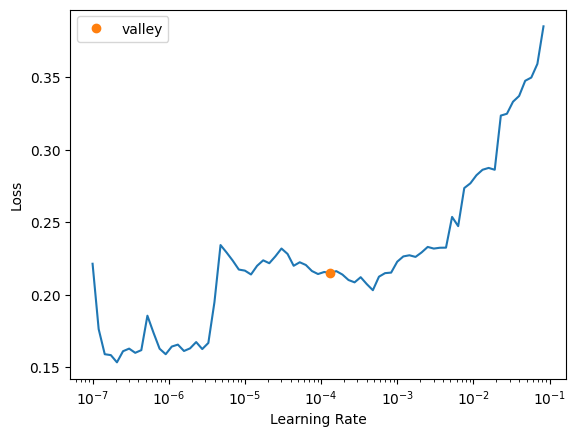

In [129]:
lr_valley = learn.lr_find(suggest_funcs=(valley,))

In [132]:
lr_valley = lr_valley.valley
lr_valley


0.00013182566908653826

In [134]:
learn.fit_one_cycle(5, lr_max=slice(lr_valley/200, lr_valley/1.5), cbs=SaveModelCallback(monitor='valid_loss', fname='resnet34'))

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.103576,0.245088,0.935874,0.990345,0.920513,0.954153,01:21
1,0.105988,0.239036,0.945167,0.990476,0.933333,0.961056,00:39
2,0.091968,0.185815,0.949814,0.990541,0.939744,0.964474,00:40
3,0.091896,0.198762,0.947026,0.990502,0.935897,0.962426,01:13
4,0.076703,0.187098,0.950743,0.990553,0.941026,0.965155,00:33


Better model found at epoch 0 with valid_loss value: 0.24508826434612274.
Better model found at epoch 1 with valid_loss value: 0.23903551697731018.
Better model found at epoch 2 with valid_loss value: 0.1858152598142624.


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

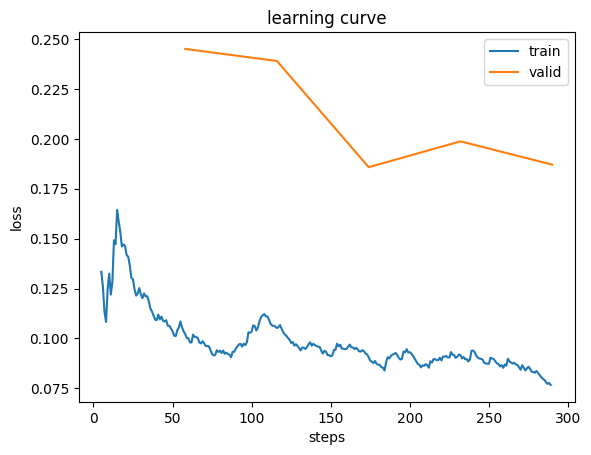

In [135]:
learn.recorder.plot_loss()

In [136]:
import gc

del learn
gc.collect()
torch.cuda.empty_cache()

### resnet50

In [137]:
from fastai.callback.fp16 import *
from fastai.metrics import RocAuc
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
import torch

<div></div>

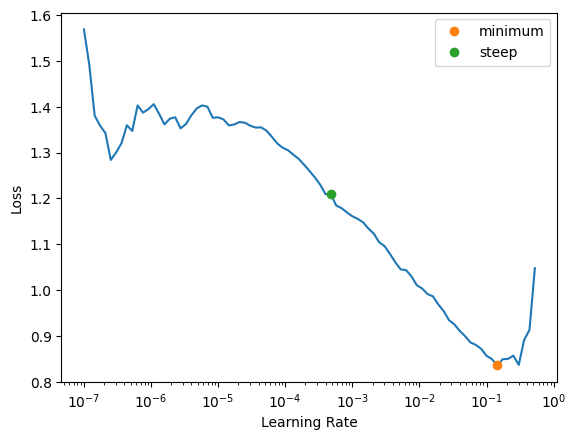

In [138]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()]).to_fp16()
lr_min,lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.438560,0.289255,0.900558,0.911873,0.955128,0.932999,00:29
1,0.272448,0.235909,0.926580,0.983448,0.914103,0.947508,00:27
2,0.190437,0.207478,0.928439,0.986169,0.914103,0.948769,00:29


Better model found at epoch 0 with valid_loss value: 0.2892550528049469.
Better model found at epoch 1 with valid_loss value: 0.23590922355651855.
Better model found at epoch 2 with valid_loss value: 0.2074781209230423.


<div></div>

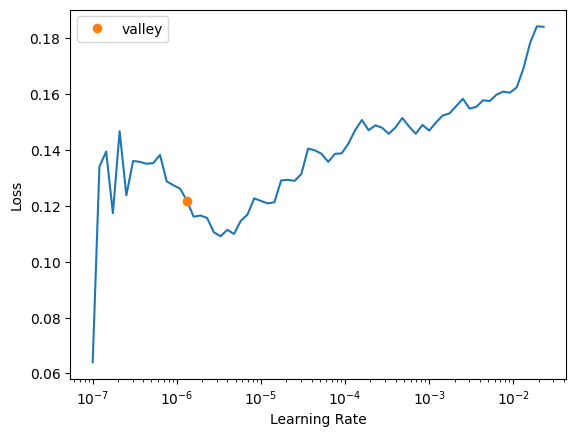

In [104]:
learn.fit_one_cycle(3, 10e-3, cbs=SaveModelCallback(monitor='valid_loss', fname='resnet50'))
learn.unfreeze()
lr_valley = learn.lr_find(suggest_funcs=(valley,)).valley

In [105]:
learn.fit_one_cycle(6, lr_max=slice(5e-8, 5e-6), cbs=SaveModelCallback(monitor='valid_loss', fname='resnet50'))

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.143520,0.206794,0.928439,0.987517,0.912821,0.948701,00:30
1,0.143402,0.206035,0.927509,0.987500,0.911538,0.948000,00:31
2,0.134423,0.196667,0.934015,0.987620,0.920513,0.952887,00:31
3,0.130117,0.189393,0.934944,0.986301,0.923077,0.953642,00:30
4,0.135875,0.219804,0.921933,0.987395,0.903846,0.943775,00:32
5,0.126739,0.209126,0.931227,0.987569,0.916667,0.950798,00:31


Better model found at epoch 0 with valid_loss value: 0.20679420232772827.
Better model found at epoch 1 with valid_loss value: 0.20603527128696442.
Better model found at epoch 2 with valid_loss value: 0.19666677713394165.
Better model found at epoch 3 with valid_loss value: 0.1893930435180664.


In [ ]:
import gc

del learn
gc.collect()
torch.cuda.empty_cache()

### densenet121

In [141]:
learn = vision_learner(dls, densenet121, metrics=[accuracy, Precision(), Recall(), F1Score()]).to_fp16()

In [ ]:
lr_min,lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.373283,42.867302,0.278810,1.000000,0.005128,0.010204,00:31
1,0.226724,0.165932,0.947026,0.990502,0.935897,0.962426,00:31
2,0.156408,0.139447,0.956320,0.989319,0.950000,0.969261,00:32


Better model found at epoch 0 with valid_loss value: 42.86730194091797.
Better model found at epoch 1 with valid_loss value: 0.16593243181705475.
Better model found at epoch 2 with valid_loss value: 0.13944675028324127.


<div></div>

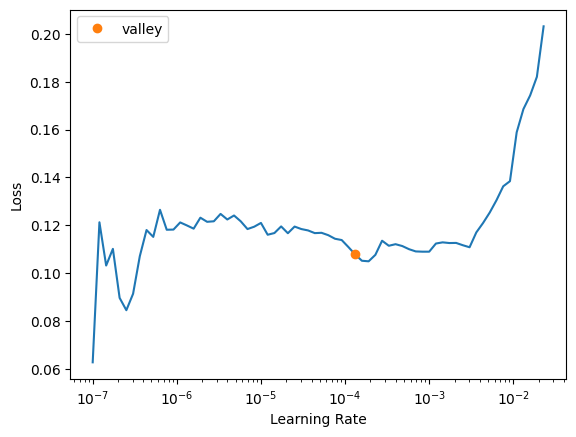

In [108]:
learn.fit_one_cycle(3, 4e-3, cbs=SaveModelCallback(monitor='valid_loss', fname='densenet121'))
learn.unfreeze()
lr_valley = learn.lr_find(suggest_funcs=(valley,)).valley

In [109]:
learn.fit_one_cycle(6, lr_max=slice(lr_valley/100, lr_valley), cbs=SaveModelCallback(monitor='valid_loss', fname='densenet121'))

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.113256,0.194109,0.940520,0.990411,0.926923,0.957616,00:31
1,0.100400,0.197485,0.934015,0.991678,0.916667,0.952698,00:32
2,0.100011,0.188940,0.939591,0.991747,0.924359,0.956868,00:30
3,0.102023,0.168610,0.944238,0.991803,0.930769,0.960317,00:31
4,0.096623,0.147944,0.950743,0.990553,0.941026,0.965155,00:32
5,0.095195,0.151889,0.950743,0.990553,0.941026,0.965155,00:30


Better model found at epoch 0 with valid_loss value: 0.19410870969295502.
Better model found at epoch 2 with valid_loss value: 0.1889401376247406.
Better model found at epoch 3 with valid_loss value: 0.1686103790998459.
Better model found at epoch 4 with valid_loss value: 0.14794445037841797.


Based on these results, I'm going to increase the number of frozen epochs and try a slightly lower learning rate to prevent the massive loss seen in epoch 0. The unfrozen epochs actually performed worse than the initial fit

In [110]:
learn = vision_learner(dls, densenet121, metrics=[accuracy, Precision(), Recall(), F1Score()]).to_fp16()
learn.fit_one_cycle(5, 9e-4, cbs=SaveModelCallback(monitor='valid_loss', fname='densenet121'))

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.627534,0.370723,0.874535,0.990868,0.834615,0.906054,00:31
1,0.360662,0.350003,0.915428,0.992847,0.889744,0.938472,00:33
2,0.230257,0.175744,0.955390,0.986702,0.951282,0.968668,00:30
3,0.170697,0.163115,0.962825,0.990716,0.957692,0.973924,00:31
4,0.128045,0.187646,0.957249,0.990642,0.950000,0.969895,00:31


Better model found at epoch 0 with valid_loss value: 0.37072309851646423.
Better model found at epoch 1 with valid_loss value: 0.35000258684158325.
Better model found at epoch 2 with valid_loss value: 0.17574356496334076.
Better model found at epoch 3 with valid_loss value: 0.16311487555503845.


c:\Users\chris\PycharmProjects\pneumonia-detection\.venv\Lib\site-packages\fastai\learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


<div></div>

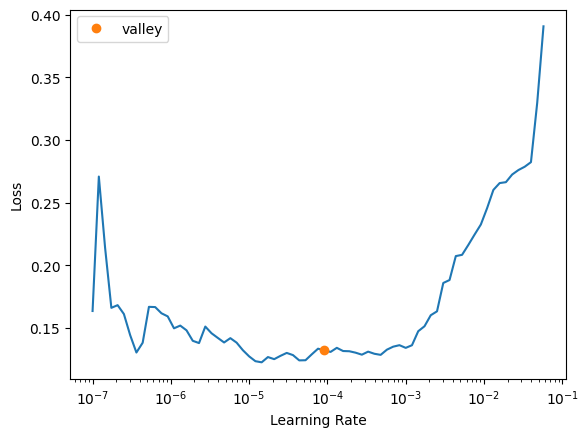

In [111]:
learn.load('densenet121')
learn.unfreeze()
lr_valley = learn.lr_find(suggest_funcs=(valley,)).valley

Because the unfrozen model seemed to be overfitting earlier, I'm dropping the learning rates further in an attempt to improve performance without overfitting

In [ ]:
learn.fit_one_cycle(3, lr_max=slice(lr_valley/10000, lr_valley/100))

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.123675,0.183040,0.960037,0.990679,0.953846,0.971914,00:34
1,0.126044,0.209132,0.956320,0.991946,0.947436,0.969180,00:37
2,0.122283,0.185043,0.956320,0.990629,0.948718,0.969221,00:35


Still underperforming, So I'll stick with the frozen epochs only. It is also the best performing of the three models

### Final modifications

In [ ]:
learn.load('densenet121')

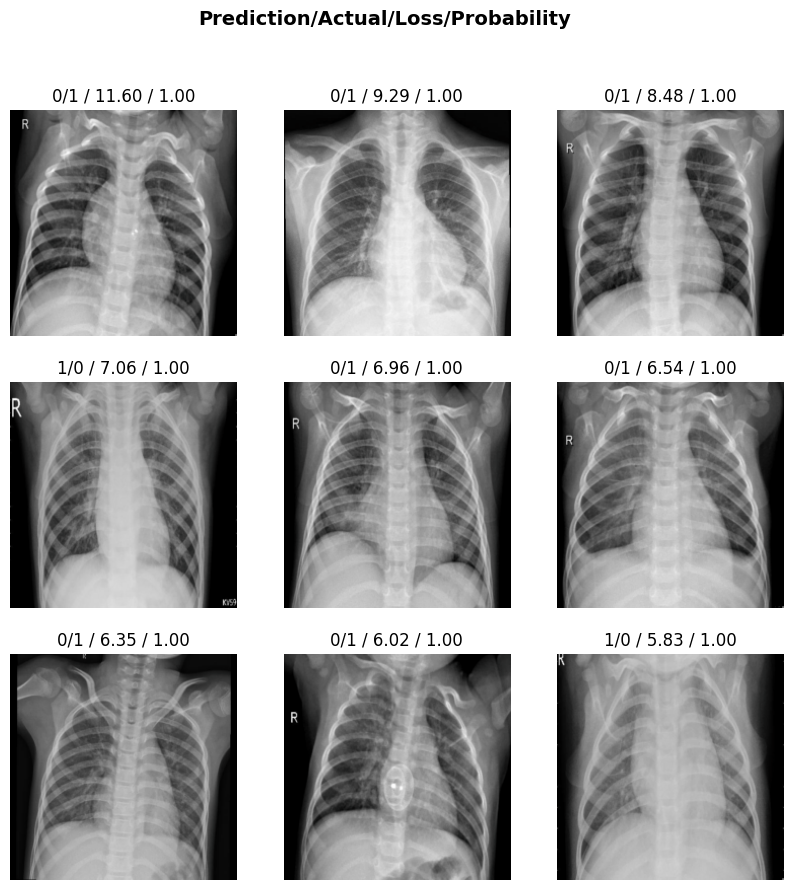

In [161]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_top_losses(k=9, figsize=(10, 10))

I am unable to identify any common patterns/significant anomalies amongst these images to modify transforms.

In [146]:
preds, targs = learn.get_preds()

# Test different thresholds
for thresh in [0.5, 0.4, 0.3, 0.2]:
    predicted = (preds[:, 1] > thresh).long()
    print(f"\nThreshold: {thresh}")
    print(classification_report(targs, predicted, target_names=['NORMAL', 'PNEUMONIA']))


Threshold: 0.5
              precision    recall  f1-score   support

      NORMAL       0.90      0.98      0.94       296
   PNEUMONIA       0.99      0.96      0.97       780

    accuracy                           0.96      1076
   macro avg       0.94      0.97      0.95      1076
weighted avg       0.97      0.96      0.96      1076


Threshold: 0.4
              precision    recall  f1-score   support

      NORMAL       0.90      0.98      0.94       296
   PNEUMONIA       0.99      0.96      0.98       780

    accuracy                           0.96      1076
   macro avg       0.95      0.97      0.96      1076
weighted avg       0.97      0.96      0.97      1076


Threshold: 0.3
              precision    recall  f1-score   support

      NORMAL       0.91      0.97      0.94       296
   PNEUMONIA       0.99      0.96      0.98       780

    accuracy                           0.97      1076
   macro avg       0.95      0.97      0.96      1076
weighted avg       0.97   

Threshold tuning didnt really change anything here

In [156]:
preds_tta, targs_tta = learn.tta(dl=dls.valid)

# Compare at default threshold first
predicted_tta = preds_tta.argmax(dim=1)
print(classification_report(targs_tta, predicted_tta, target_names=['NORMAL', 'PNEUMONIA']))

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time


<div></div>

              precision    recall  f1-score   support

      NORMAL       0.94      0.97      0.95       296
   PNEUMONIA       0.99      0.98      0.98       780

    accuracy                           0.97      1076
   macro avg       0.96      0.97      0.97      1076
weighted avg       0.97      0.97      0.97      1076



TTA appears to have improved the pneumonia recall slightly. This adjustment to the model now only misses 2% of pneumonia cases, and will be the final iteration to be weighed against the test set.

### Final Results & Conclusion

In [162]:
learn.load('densenet121')

c:\Users\chris\PycharmProjects\pneumonia-detection\.venv\Lib\site-packages\fastai\learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


In [166]:
test_df_pandas = test_df.to_pandas()

test_dl = dls.test_dl(test_df_pandas[['file_path', 'label']], with_labels=True)
preds_test, targs_test = learn.tta(dl=test_dl)

predicted_test = preds_test.argmax(dim=1)
print(classification_report(targs_test, predicted_test, target_names=['NORMAL', 'PNEUMONIA']))

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time


<div></div>

              precision    recall  f1-score   support

      NORMAL       0.97      0.93      0.95       147
   PNEUMONIA       0.97      0.99      0.98       392

    accuracy                           0.97       539
   macro avg       0.97      0.96      0.97       539
weighted avg       0.97      0.97      0.97       539



DenseNet121 trained with frozen backbone weights outperformed both ResNet variants across all metrics. Notably, unfreezing the DenseNet121 backbone actually degraded performance in multiple tests, suggesting that the pretrained features are well suited for X-ray imagery. The classification threshold remained at 0.5 as changes did not show any meaningful changes to performance, suggesting that the model's predictions tend to be very confident. TTA, however, did improve the performance of the model and was used in the final iteration. There was actually an increase in performance on the test set compared to the validation set, which reflects well on the generalization of the model. Because this is a medical dataset and the cost of a false negative far outweighs the cost of a false positive, strong recall and f1 scores were prioritized. The final version of the model had a recall score of 0.99 and F1 score of 0.98, meaning that only 1 in 100 positive cases were missed.